In [1]:
"""
Script to visualize pseudobulk splicing PSI data from the long format file
"""

# Load packages we need
import pandas as pd
import os
import sys
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from typing import List, Set, Dict, Any, Optional
from scipy import stats
from sklearn.decomposition import PCA
import gffutils
import random

# Alternatively, you can directly specify the path
module_path = "/gpfs/commons/home/kisaev/LeafletFA-utils"

# Add path if not already in sys.path
if module_path not in sys.path:
    sys.path.append(module_path)
    print(f"Added {module_path} to sys.path")

# Now you should be able to import from leafletfa_utils
from leafletfa_utils.atsemapper.main import run_atsemapper # type: ignore
from leafletfa_utils.atseviz.main import * # type: ignore
print("Imports successful!")

# ----- Configuration -----

# Set random seed for reproducibility
np.random.seed(42)
random.seed(42)

# Output directory
output_dir = "/gpfs/commons/groups/knowles_lab/Karin/Leaflet-analysis-WD/HUMAN_SPLICING_FOUNDATION/visualizations"
os.makedirs(output_dir, exist_ok=True)
print(f"Output directory: {output_dir}")

# Timestamp for file naming
timestamp = pd.Timestamp.now().strftime('%Y%m%d_%H%M%S')

# Set default matplotlib parameters
plt.rcParams.update({
    'font.size': 10,
    'axes.titlesize': 12,
    'axes.labelsize': 11,
    'xtick.labelsize': 9,
    'ytick.labelsize': 9,
    'legend.fontsize': 9,
    'figure.titlesize': 14
})


Added /gpfs/commons/home/kisaev/LeafletFA-utils to sys.path
Imports successful!
Output directory: /gpfs/commons/groups/knowles_lab/Karin/Leaflet-analysis-WD/HUMAN_SPLICING_FOUNDATION/visualizations


In [2]:
# ----- Load data -----
pseudobulk_file = "/gpfs/commons/groups/knowles_lab/Karin/Leaflet-analysis-WD/HUMAN_SPLICING_FOUNDATION/MODEL_INPUT/052025/pseudobulk_final_broad_cell_type_20250514_072922.csv.gz"
print(f"Loading pseudobulk data from: {pseudobulk_file}")
long_df = pd.read_csv(pseudobulk_file, low_memory=False)
print(f"Loaded {len(long_df)} rows of data with {long_df['cell_type'].nunique()} cell types")

# Load ATSE data
ATSE_file = "/gpfs/commons/groups/knowles_lab/Karin/Leaflet-analysis-WD/HUMAN_SPLICING_FOUNDATION/ATSE_mapper/ATSE_files/stella_gtf/TMS_atse_file_unanno_also_2025-05-11_06-23-05.txt.gz"
atses = pd.read_csv(ATSE_file, sep="\t")
print(f"Loaded {len(atses)} rows of ATSE data with {len(atses['event_id'].unique())} unique events")

# Load human DB file if available
try:
    db_file = "/gpfs/commons/groups/knowles_lab/Karin/Leaflet-analysis-WD/HUMAN_SPLICING_FOUNDATION/ATSE_mapper/hg38_stella_gtf"
    db = gffutils.FeatureDB(db_file, keep_order=True)
    print("Loaded genome database successfully")
    genome_db_available = True
except Exception as e:
    print(f"Warning: Could not load genome database: {e}")
    genome_db_available = False

Loading pseudobulk data from: /gpfs/commons/groups/knowles_lab/Karin/Leaflet-analysis-WD/HUMAN_SPLICING_FOUNDATION/MODEL_INPUT/052025/pseudobulk_final_broad_cell_type_20250514_072922.csv.gz
Loaded 7245157 rows of data with 29 cell types
Loaded 249833 rows of ATSE data with 57924 unique events
Loaded genome database successfully


In [3]:
long_df.head()

,cell_type,junction_id,junction_id_index,junction_count,atse_count,psi,n_cells,gene_id,event_id,gene_symbol
0,Pigment cell,chrX_100635746_100636190_-,242239,0.0,0.0,NaN,24,ENSG00000000003.16,ENSG00000000003.16_atse_1,TSPAN6
1,Neuron,chrX_100636207_100636792_-,242242,191.0,2058.0,0.092809,42627,ENSG00000000003.16,ENSG00000000003.16_atse_1,TSPAN6
2,Microglia_Macrophage,chrX_100635746_100636190_-,242239,0.0,2.0,0.000000,3232,ENSG00000000003.16,ENSG00000000003.16_atse_1,TSPAN6
3,Pericyte,chrX_100636207_100636792_-,242242,0.0,1901.0,0.000000,655,ENSG00000000003.16,ENSG00000000003.16_atse_1,TSPAN6
4,Pericyte,chrX_100635746_100636792_-,242241,44.0,1901.0,0.023146,655,ENSG00000000003.16,ENSG00000000003.16_atse_1,TSPAN6


In [4]:
atses.head()

,event_id,gene_id,gene_name,gene_types,num_junctions,event_type,chromosome,strand,atse_start,atse_end,...,three_prime_usage,donor_usage,acceptor_usage,donor_total_reads,acceptor_total_reads,splice_motif,donor_seq,acceptor_seq,position_off_5_prime,position_off_3_prime
0,ENSG00000221978.13_atse_1,ENSG00000221978.13,NaN,NaN,2,alternative_5_prime,chr1,-,1387297,1399112,...,0.7705,0.7705,1.0000,61,47,GT-AG,GT,AG,-93.0,NaN
1,ENSG00000221978.13_atse_1,ENSG00000221978.13,NaN,NaN,2,alternative_5_prime,chr1,-,1387297,1399112,...,1.0000,1.0000,0.2295,14,61,GT-AG,GT,AG,-32.0,NaN
2,ENSG00000221978.13_atse_2,ENSG00000221978.13,NaN,NaN,2,alternative_5_prime,chr1,-,1398671,1399018,...,1.0000,1.0000,0.9698,218619,225419,GT-AG,GT,AG,1.0,0.0
3,ENSG00000221978.13_atse_2,ENSG00000221978.13,NaN,NaN,2,alternative_5_prime,chr1,-,1398671,1399018,...,0.0302,0.0302,1.0000,225419,6810,GT-AG,GT,AG,1.0,0.0
4,ENSG00000221978.13_atse_3,ENSG00000221978.13,NaN,NaN,2,alternative_3_prime,chr1,-,1398342,1398596,...,0.9824,0.9824,0.9984,309719,304754,GT-AG,GT,AG,1.0,0.0


#### Input: Gene ID or symbol and output: Clustermap output with all gene-junctions-ATSEs displayed PSI by major cell type group

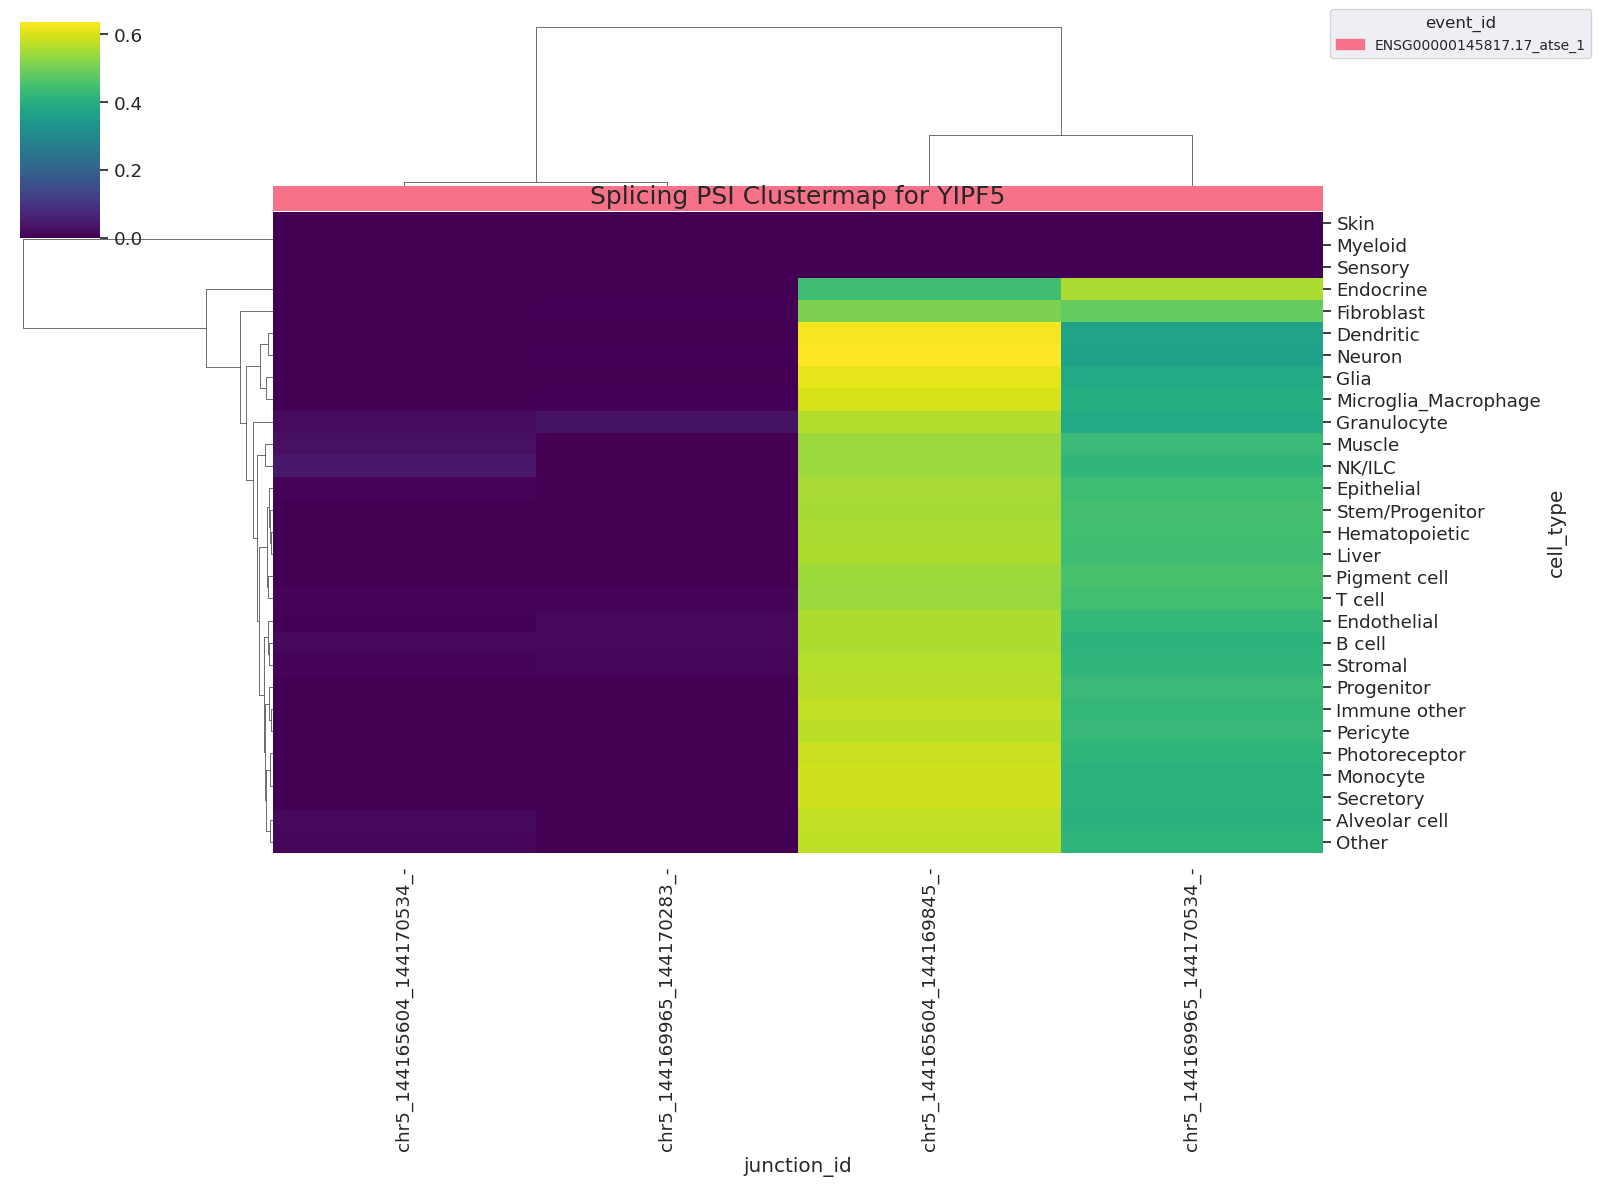

In [5]:
# Sample gene name from your dataset
gene_name = np.random.choice(long_df["gene_symbol"].unique(), 1)[0]
gene_vals = long_df[long_df["gene_symbol"] == gene_name]

# Pivot to create a matrix: rows = cell types, columns = junctions, values = PSI
psi_matrix = gene_vals.pivot(index='cell_type', columns='junction_id', values='psi')

# Replace NaNs with 0 (or use another strategy)
psi_matrix = psi_matrix.fillna(0)

# Map junctions to event_ids
junction_to_event = gene_vals.drop_duplicates(subset='junction_id')[['junction_id', 'event_id']]
junction_to_event = junction_to_event.set_index('junction_id')['event_id']

# Create a color palette for event IDs
unique_events = junction_to_event.loc[psi_matrix.columns].unique()
event_palette = sns.color_palette("husl", len(unique_events))
event_lut = dict(zip(unique_events, event_palette))

# Color annotation per junction
col_colors = psi_matrix.columns.map(junction_to_event).map(event_lut)

# Set global font scale
sns.set(font_scale=1.2)

# Generate the clustermap
g = sns.clustermap(
    psi_matrix,
    cmap='viridis',
    col_colors=col_colors,
    figsize=(16, 12),
    xticklabels=True,
    yticklabels=True
)

# Add title with gene name
g.ax_heatmap.set_title(f"Splicing PSI Clustermap for {gene_name}", fontsize=18)

# Add legend for event_ids to the right of the heatmap
from matplotlib.patches import Patch
handles = [Patch(color=event_lut[eid], label=eid) for eid in unique_events]
g.ax_col_dendrogram.legend(
    handles=handles,
    title='event_id',
    bbox_to_anchor=(1.0, 1.1),
    loc='upper left',
    fontsize=10,
    title_fontsize=12
)

plt.show()


Processing ENSG00000145817.17_atse_1...
Found 17 transcripts for ENSG00000145817.17_atse_1
Plot saved to ENSG00000145817.17_atse_1.pdf!


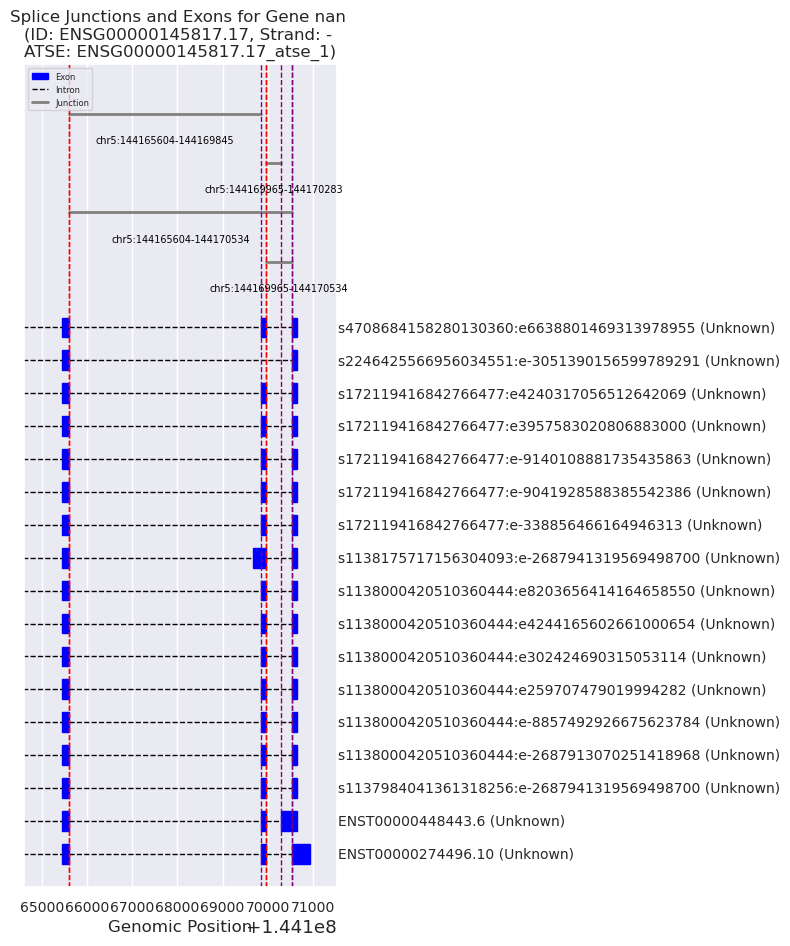

Saved plot to ENSG00000145817.17_atse_1.pdf


In [ ]:
# Loop over all unique ATSE event IDs
for atse_event in gene_vals["event_id"].unique():
    print(f"Processing {atse_event}...")

    try:
        # Subset and prepare junctions for this ATSE
        juncs = atses[atses["event_id"] == atse_event].copy()
        if juncs.empty:
            print(f"No junctions found for {atse_event}, skipping.")
            continue

        # Normalize usage_ratio
        total_score_sum = juncs["total_score"].sum()
        if total_score_sum == 0:
            print(f"Total score is zero for {atse_event}, skipping.")
            continue

        juncs.loc[:, "usage_ratio"] = juncs["total_score"] / total_score_sum
        juncs.loc[:, "Cluster"] = juncs["event_id"]

        # Convert junctions to plotting format
        splice_junctions = convert_junction_ids(juncs)

        # Extract associated transcripts
        unique_transcripts = extract_unique_transcripts(juncs)
        if len(unique_transcripts) == 0:
            print(f"No transcripts found for {atse_event}, skipping.")
            continue

        # Fetch transcript annotations
        transcript_data = fetch_transcripts_and_annotations(db, unique_transcripts)

        # Extract transcript metadata
        conversions = {}
        for t in transcript_data.keys():
            conversions[t] = {
                "transcript_name": transcript_data[t]["transcript_name"],
                "transcript_type": transcript_data[t]["transcript_type"],
                "transcript_id": transcript_data[t]["transcript_id"]
            }

        conversions_df = pd.DataFrame.from_dict(conversions, orient="index")
        print(f"Found {len(conversions_df)} transcripts for {atse_event}")

        # Determine region to plot
        region_start, region_end = determine_region_boundaries(splice_junctions)

        # Output filename per event
        filename = f"{atse_event.replace(':', '_')}.pdf"

        # Plot the event
        plot_exons_and_junctions(
            db,
            atse_event,
            transcript_data,
            splice_junctions,
            region_start,
            region_end,
            base_width=8,
            trans_height=0.5,
            show_usage=False,
            show_junc_lines=True,
            filename=filename
        )

        print(f"Saved plot to {filename}")

    except Exception as e:
        print(f"Error processing {atse_event}: {e}")

# Select junction from dropdown and grey out the transcripts that don't contain it... 
# Something to make it easier to see junction to transcript relationships... 
# Decide if want to show the novel isoforms or not... 
# Github repo for Dashboard to move to knowles lab github repo